<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/TugasRumahLangkah4-7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics
!unzip -q "Program - Object Detection.zip" -d /content/dataset_tugas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.3 MB/s eta 0:00:00


In [3]:
import os
import glob
from ultralytics import YOLO

# 1. Melacak otomatis lokasi folder train dan valid di dalam Colab
train_search = glob.glob('/content/**/train/images', recursive=True)
val_search = glob.glob('/content/**/valid/images', recursive=True)

# (Antisipasi jika foldernya dinamai 'val' alih-alih 'valid')
if not val_search:
    val_search = glob.glob('/content/**/val/images', recursive=True)

if train_search and val_search:
    train_path = train_search[0]
    val_path = val_search[0]

    print(f"✅ Folder dataset ditemukan!")

    # 2. Membuat file YAML baru dengan alamat mutlak (pasti terbaca)
    yaml_text = f"""
train: '{train_path}'
val: '{val_path}'
nc: 3
names: ['head', 'helmet', 'person']
"""
    yaml_path = "/content/data_super_aman.yaml"
    with open(yaml_path, "w") as f:
        f.write(yaml_text.strip())

    print("✅ Konfigurasi baru berhasil dibuat. Memulai proses training...\n")

    # 3. Menjalankan model YOLO
    model = YOLO("yolo11n.pt")
    train_results = model.train(
        data=yaml_path,
        epochs=25,
        imgsz=640,
        device="cpu"
    )

else:
    print("❌ Error: Folder gambar tidak ditemukan. Pastikan file 'Program - Object Detection.zip' sudah ter-upload dan diekstrak dengan benar.")

✅ Folder dataset ditemukan!
✅ Konfigurasi baru berhasil dibuat. Memulai proses training...

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_super_aman.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, n

✅ Model ditemukan di: runs/detect/train-2/weights/best.pt

Membuka kamera... (Mohon klik 'Allow/Izinkan' jika muncul popup di bagian atas browser)


<IPython.core.display.Javascript object>

✅ Foto berhasil diambil! Sedang melakukan deteksi objek...

image 1/1 /content/photo.jpg: 480x640 (no detections), 187.3ms
Speed: 4.6ms preprocess, 187.3ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


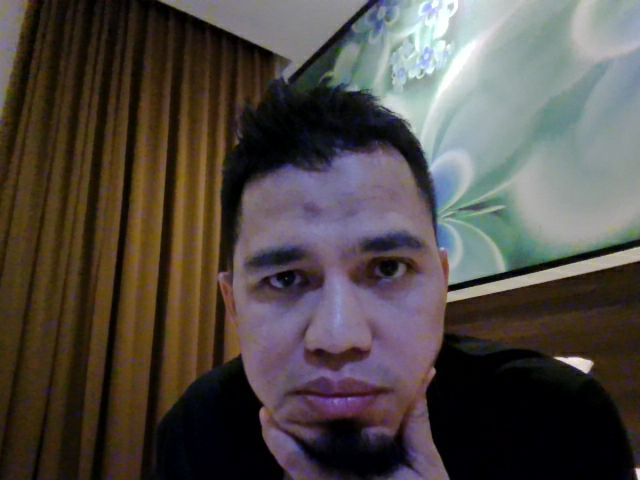

In [6]:
import glob
import os
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
from ultralytics import YOLO

# 1. Mencari otomatis di mana letak model terbaru yang berhasil dilatih
list_model = glob.glob('runs/detect/*/weights/best.pt')
if not list_model:
    list_model = glob.glob('/content/runs/detect/*/weights/best.pt')

if not list_model:
    print("❌ Model best.pt belum ditemukan! Tolong pastikan proses training (Langkah 2) sudah benar-benar selesai 100%.")
else:
    # Mengambil model yang paling terakhir dibuat
    model_terbaru = max(list_model, key=os.path.getmtime)
    print(f"✅ Model ditemukan di: {model_terbaru}")

    # Memuat model
    model_custom = YOLO(model_terbaru)

    # 2. Fungsi WebCam khusus Google Colab
    def take_photo_and_detect(filename='photo.jpg', quality=0.8):
      js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = '📸 Klik Disini Untuk Foto';
          capture.style.padding = '10px';
          capture.style.backgroundColor = '#28a745';
          capture.style.color = 'white';
          capture.style.fontSize = '16px';
          capture.style.border = 'none';
          capture.style.cursor = 'pointer';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          video.style.marginTop = '10px';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

          // Menunggu tombol diklik
          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
      display(js)
      data = eval_js('takePhoto({})'.format(quality))
      binary = b64decode(data.split(',')[1])
      with open(filename, 'wb') as f:
        f.write(binary)

      print("✅ Foto berhasil diambil! Sedang melakukan deteksi objek...")

      # Melakukan inferensi menggunakan model YOLO
      results = model_custom(filename)

      # Menampilkan hasil
      im_array = results[0].plot()
      im = Image.fromarray(im_array[..., ::-1])
      display(im)

    try:
      print("\nMembuka kamera... (Mohon klik 'Allow/Izinkan' jika muncul popup di bagian atas browser)")
      take_photo_and_detect()
    except Exception as err:
      print("❌ Kamera gagal diakses. Pastikan browser Anda memberi izin akses kamera.")
      print("Detail error:", str(err))